# 02 — Hijerarhijsko klasteriranje faktorskih izloženosti

Faza 3 projekta s kliznim prozorom.

1. Odaberi jedan broj klastera *K* maksimiziranjem prosječne siluete kroz
   klizne prozore, uz uvjet da svaki klaster nosi ≥ 4 dionice u svakom
   prozoru.
2. Prilagodi faktorska i korelacijska klasteriranja na svakom prozoru treniranja s
   odabranim *K*; spremi tablice klastera u dugom formatu.
3. Dijagnosticiraj najnoviji (reprezentativni) prozor: dendrogram, radar-grafove
   centroida klastera, UMAP prostora faktora i usporedbu jedan-do-drugoga
   s GICS sektorima.
4. Bootstrap ponovno uzorkuj reprezentativni prozor radi usporedbe stabilnosti
   faktorskih i korelacijskih klastera (Jaccard na parovima zajedničke pripadnosti).


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.clustering import (
    FACTOR_FEATURE_COLUMNS,
    cluster_all_windows,
    cluster_stability,
    compare_clusterings,
    correlation_cluster,
    factor_cluster,
)
from src.backtest import generate_rolling_windows
from src.utils import (
    FIGURES_DIR,
    N_BOOTSTRAP_CLUSTERS,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
metadata = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
windows = generate_rolling_windows()
print(f"{len(windows)} kliznih prozora; {factor_exposures['train_window'].nunique()} prisutno u faktorskim izloženostima.")


16 kliznih prozora; 16 prisutno u faktorskim izloženostima.


## 2.1 Odaberi K prema prosječnoj silueti kroz prozore


In [3]:
candidate_ks = list(range(3, 13))
records = []
for k in candidate_ks:
    silhouettes = []
    min_cluster_sizes = []
    for window in windows:
        feats = factor_exposures.loc[
            factor_exposures["train_window"] == window.label
        ].set_index("ticker")[FACTOR_FEATURE_COLUMNS]
        if len(feats) < k + 1:
            continue
        labels, _ = factor_cluster(feats, k=k)
        try:
            sil = silhouette_score(StandardScaler().fit_transform(feats), labels)
        except ValueError:
            continue
        silhouettes.append(sil)
        min_cluster_sizes.append(labels.value_counts().min())
    if silhouettes:
        records.append(
            {
                "k": k,
                "mean_silhouette": float(np.mean(silhouettes)),
                "min_cluster_size_any_window": int(min(min_cluster_sizes)),
                "n_windows": len(silhouettes),
            }
        )
silhouette_table = pd.DataFrame(records)
print(silhouette_table)
silhouette_table.to_csv(TABLES_DIR / "02_silhouette_by_k.csv", index=False)


    k  mean_silhouette  min_cluster_size_any_window  n_windows
0   3         0.167050                           15         16
1   4         0.140324                            9         16
2   5         0.129040                            9         16
3   6         0.125766                            5         16
4   7         0.122805                            5         16
5   8         0.110935                            5         16
6   9         0.111189                            4         16
7  10         0.114493                            2         16
8  11         0.116836                            1         16
9  12         0.114804                            1         16


In [4]:
from src.utils import GROUP_CAP, W_MAX

# Portfelj sa samo dugim pozicijama s ograničenjem po klasteru `u` i ograničenjem pozicije `w_max` treba
# K × u ≥ 1 da bi bio potpuno investibilan. Uz u=0.15 i w_max=0.02 to implicira
# K ≥ 7. Također zahtijevamo min_cluster_size_any_window ≥ 4 kako bi svaki klaster mogao
# apsorbirati smislen udio grupnog ograničenja (4 dionice × 2% = 8%, pri čemu je
# ograničenje aktivno na u=15% samo kad je klaster dovoljno velik — ali
# kvadratni program i dalje može alocirati efektivni kapacitet klastera).
min_k_for_feasibility = int(np.ceil(1.0 / GROUP_CAP))
print(f"Minimalni K za izvedivost ograničenja klastera = {min_k_for_feasibility} (group_cap={GROUP_CAP})")

feasible = silhouette_table.loc[
    (silhouette_table["min_cluster_size_any_window"] >= 4)
    & (silhouette_table["k"] >= min_k_for_feasibility)
]
if feasible.empty:
    raise RuntimeError(
        "Nijedan K ne zadovoljava istodobno ograničenja veličine klastera ≥ 4 i "
        "K × group_cap ≥ 1. Povisi group_cap ili snizi w_max."
    )
chosen_k = int(feasible.loc[feasible["mean_silhouette"].idxmax(), "k"])
print(f"Odabran K = {chosen_k}")
print(feasible)


Minimalni K za izvedivost ograničenja klastera = 7 (group_cap=0.15)
Odabran K = 7
   k  mean_silhouette  min_cluster_size_any_window  n_windows
4  7         0.122805                            5         16
5  8         0.110935                            5         16
6  9         0.111189                            4         16


**Pravilo odluke.** Uzmi K s najvišom prosječnom siluetom kroz sve
klizne prozore uz:

1. Svaki klaster nosi barem 4 dionice u svakom prozoru (tako da je grupno
   ograničenje od 15% aktivno, a ne izgladnjelo — 4 dionice × 2% = 8%, kvadratni program iskoristit će
   samo dio efektivnog kapaciteta klastera od 15%, ali je
   ograničenje dobro definirano).
2. ``K × group_cap ≥ 1`` tako da je portfelj sa samo dugim pozicijama potpuno investibilan
   pod ograničenjem klastera (``K ≥ ⌈1/group_cap⌉ = ⌈1/0.15⌉ = 7``).

Ograničenje (2) slijedi iz konstrukcije sa samo dugim pozicijama: svaki klaster
doprinosi najviše ``group_cap`` ukupnoj težini, pa K klasterskih suma
mora dati barem 1. Bez toga je kvadratni program ograničen klasterima neizvediv,
a *cijeli protok* tiho bi se vratio na neograničeno
rješenje minimalne varijance.


## 2.2 Prilagodi klasteriranje na svakom prozoru i pohrani


In [5]:
cluster_tables = cluster_all_windows(
    factor_exposures=factor_exposures,
    monthly_returns=monthly_returns,
    windows=windows,
    k=chosen_k,
    metadata=metadata,
)
factor_clusters = cluster_tables["factor_clusters"]
correlation_clusters = cluster_tables["correlation_clusters"]
factor_clusters.to_csv(PROCESSED_DATA_DIR / "factor_clusters.csv", index=False)
correlation_clusters.to_csv(PROCESSED_DATA_DIR / "correlation_clusters.csv", index=False)
print("Faktorski klasteri:", factor_clusters.shape)
print("Korelacijski klasteri:", correlation_clusters.shape)


Faktorski klasteri: (11762, 4)
Korelacijski klasteri: (11762, 4)


## 2.3 Dijagnostika reprezentativnog prozora


In [6]:
rep_window = windows[-1]
print("Reprezentativni prozor:", rep_window.label)

rep_features = (
    factor_exposures.loc[factor_exposures["train_window"] == rep_window.label]
    .set_index("ticker")[FACTOR_FEATURE_COLUMNS]
)
rep_factor_labels, rep_factor_linkage = factor_cluster(rep_features, k=chosen_k)

rep_returns = monthly_returns.loc[
    rep_window.train_start:rep_window.train_end, rep_features.index
].dropna(axis=0, how="any")
rep_corr_labels, _ = correlation_cluster(rep_returns, k=chosen_k)
print("Veličine faktorskih klastera:", rep_factor_labels.value_counts().to_dict())
print("Veličine korelacijskih klastera:", rep_corr_labels.value_counts().to_dict())


Reprezentativni prozor: 2024-12
Veličine faktorskih klastera: {6: 237, 4: 201, 2: 172, 5: 132, 3: 70, 1: 49, 7: 23}
Veličine korelacijskih klastera: {5: 333, 6: 225, 4: 155, 2: 99, 3: 39, 7: 24, 1: 9}


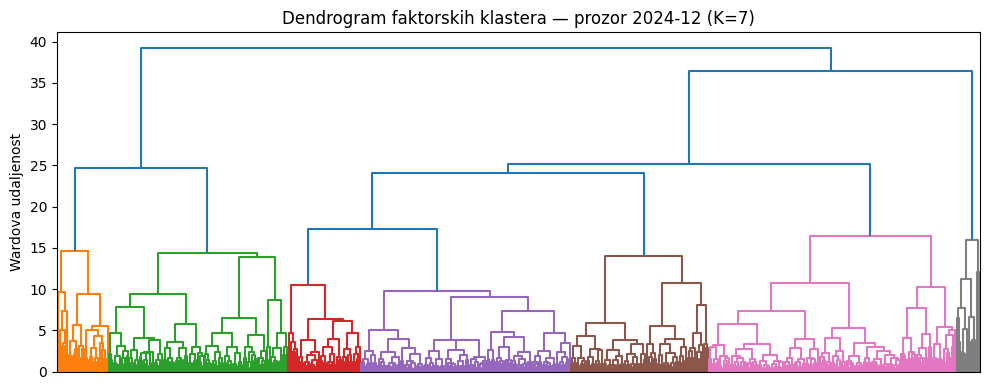

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(
    rep_factor_linkage,
    no_labels=True,
    color_threshold=rep_factor_linkage[-(chosen_k - 1), 2],
    ax=ax,
)
ax.set_title(f"Dendrogram faktorskih klastera — prozor {rep_window.label} (K={chosen_k})")
ax.set_ylabel("Wardova udaljenost")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_dendrogram_representative.png", dpi=150)
plt.show()


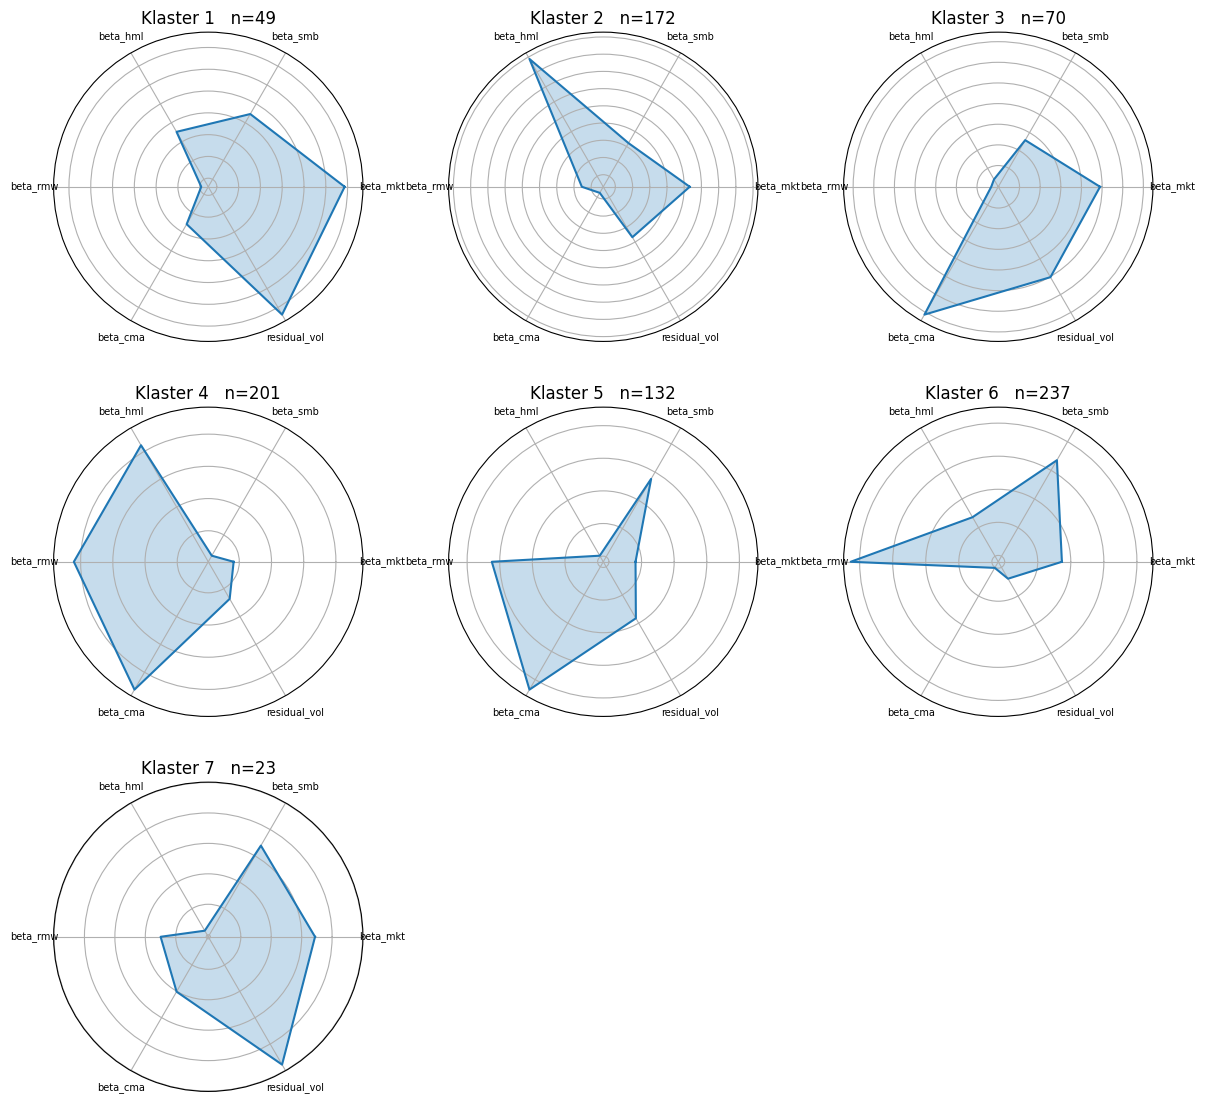

                beta_mkt  beta_smb  beta_hml  beta_rmw  beta_cma  residual_vol
factor_cluster                                                                
1                   0.93     -0.27     -0.74     -2.03     -1.21          1.19
2                   0.33     -0.19      1.22     -0.61     -0.82         -0.08
3                   0.18     -0.28     -0.72     -0.74      0.62          0.21
4                  -0.64     -0.75      0.04      0.04      0.12         -0.53
5                  -0.59      0.38     -0.98      0.62      1.18         -0.09
6                   0.15      0.47      0.07      0.65     -0.20         -0.12
7                   2.44      2.39     -0.84      0.50      1.01          3.78


In [8]:
standardized = StandardScaler().fit_transform(rep_features)
centroids = pd.DataFrame(
    standardized, index=rep_features.index, columns=FACTOR_FEATURE_COLUMNS
).groupby(rep_factor_labels).mean()

labels_radar = FACTOR_FEATURE_COLUMNS
angles = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angles += angles[:1]

n_clusters = len(centroids)
ncols = min(3, n_clusters)
nrows = int(np.ceil(n_clusters / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.8 * nrows),
                          subplot_kw={"polar": True})
axes_flat = np.atleast_1d(axes).ravel()
for ax, (cluster_id, row) in zip(axes_flat, centroids.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color="C0")
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_radar, fontsize=7)
    ax.set_yticklabels([])
    ax.set_title(f"Klaster {cluster_id}   n={int((rep_factor_labels == cluster_id).sum())}")
for ax in axes_flat[len(centroids):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_cluster_centroids_radar.png", dpi=150)
plt.show()

print(centroids.round(2))


### UMAP prostora faktora, obojen na tri načina


/Users/marinmestrovic/Desktop/personal/daozip/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


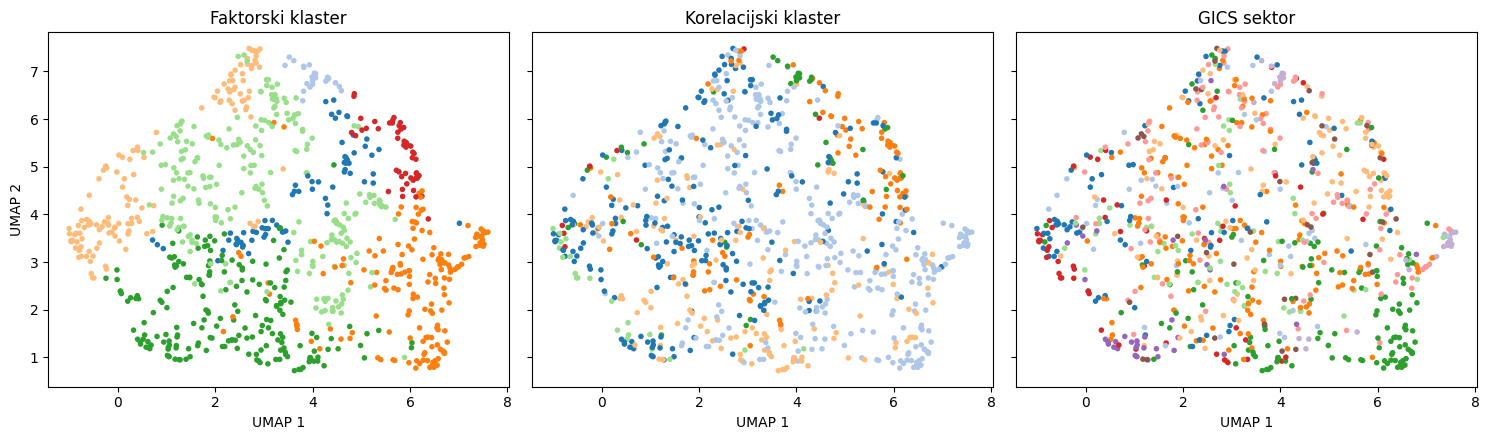

In [9]:
import umap

reducer = umap.UMAP(n_neighbors=15, random_state=42)
embedding = reducer.fit_transform(StandardScaler().fit_transform(rep_features))
emb_df = pd.DataFrame(embedding, index=rep_features.index, columns=["umap_x", "umap_y"])

sector_map = metadata.set_index("ticker")["sector"]
panels = {
    "Faktorski klaster": rep_factor_labels.astype(str),
    "Korelacijski klaster": rep_corr_labels.astype(str),
    "GICS sektor": sector_map.reindex(rep_features.index).astype(str),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (title, labels) in zip(axes, panels.items()):
    sns.scatterplot(
        x=emb_df["umap_x"],
        y=emb_df["umap_y"],
        hue=labels.values,
        ax=ax,
        s=16,
        linewidth=0,
        palette="tab20",
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_factor_umap_three_panels.png", dpi=150)
plt.show()


## 2.4 Metrike usporedbe klastera (reprezentativni prozor)


In [10]:
label_sets = {
    "factor": rep_factor_labels,
    "correlation": rep_corr_labels,
    "sector": sector_map.reindex(rep_features.index).astype(str),
}
comparison = compare_clusterings(
    label_sets=label_sets,
    factor_matrix=rep_features,
    returns=rep_returns,
)
comparison.to_csv(TABLES_DIR / "02_clustering_comparison.csv", index=False)
print(comparison)


                                    metric    label_set  compared_to  \
0                      adjusted_rand_index       factor  correlation   
1                      adjusted_rand_index       factor       sector   
2                      adjusted_rand_index  correlation       sector   
3                            sector_purity       factor       sector   
4                            sector_purity  correlation       sector   
5                  silhouette_factor_space       factor          NaN   
6   mean_within_cluster_return_correlation       factor          NaN   
7                  silhouette_factor_space  correlation          NaN   
8   mean_within_cluster_return_correlation  correlation          NaN   
9                  silhouette_factor_space       sector          NaN   
10  mean_within_cluster_return_correlation       sector          NaN   

       value  n_items  n_clusters  
0   0.115903      884         NaN  
1   0.083384      884         NaN  
2   0.047817      884      

## 2.5 Bootstrap stabilnost — faktorski naspram korelacijskih


    clustering  mean_jaccard  mean_within_cluster_comembership  \
0       factor      0.296433                          0.511750   
1  correlation      0.264160                          0.468321   

   n_bootstraps_used  
0                500  
1                500  


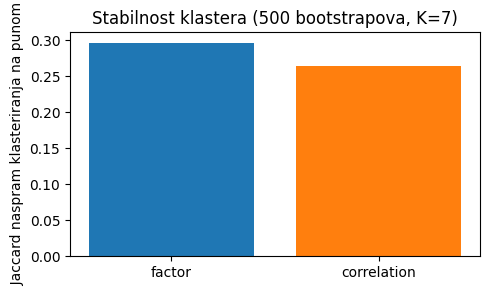

In [11]:
factor_stability = cluster_stability(
    rep_features, k=chosen_k, mode="factor", n_bootstraps=N_BOOTSTRAP_CLUSTERS
)
correlation_stability = cluster_stability(
    rep_returns, k=chosen_k, mode="correlation", n_bootstraps=N_BOOTSTRAP_CLUSTERS
)
stability_summary = pd.DataFrame(
    {
        "clustering": ["factor", "correlation"],
        "mean_jaccard": [
            factor_stability["mean_jaccard"],
            correlation_stability["mean_jaccard"],
        ],
        "mean_within_cluster_comembership": [
            factor_stability["mean_within_cluster_comembership"],
            correlation_stability["mean_within_cluster_comembership"],
        ],
        "n_bootstraps_used": [
            factor_stability["n_bootstraps_used"],
            correlation_stability["n_bootstraps_used"],
        ],
    }
)
print(stability_summary)
stability_summary.to_csv(TABLES_DIR / "02_cluster_stability.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(stability_summary["clustering"], stability_summary["mean_jaccard"],
       color=["C0", "C1"])
ax.set_ylabel("Srednji Jaccard naspram klasteriranja na punom uzorku")
ax.set_title(f"Stabilnost klastera (500 bootstrapova, K={chosen_k})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_cluster_stability_bar.png", dpi=150)
plt.show()
